In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from PIL import Image

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [10]:
target_class = "helicopter"

real_train_path = "/content/drive/MyDrive/airborne-object-detection/dataset/train"

image_size = 64
batch_size = 32

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

full_dataset = ImageFolder(root=real_train_path, transform=transform)

print("Classes:", full_dataset.classes)

class_idx = full_dataset.class_to_idx[target_class]

indices = [
    i for i, (_, label) in enumerate(full_dataset.samples)
    if label == class_idx
]

helicopter_dataset = torch.utils.data.Subset(full_dataset, indices)

dataloader = DataLoader(
    helicopter_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Helicopter image count:", len(helicopter_dataset))

Classes: ['airplane', 'bird', 'drone', 'helicopter']
Helicopter image count: 4255


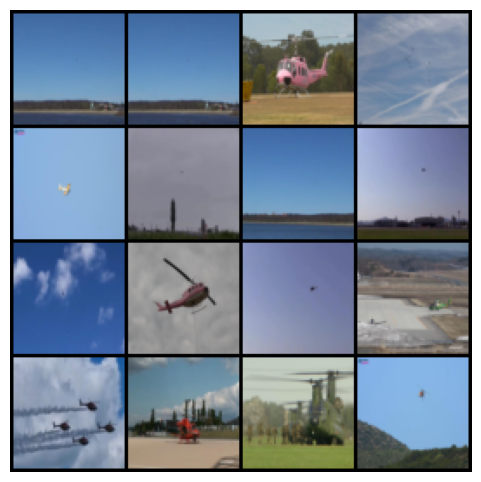

In [11]:
real_batch = next(iter(dataloader))
images = real_batch[0][:16]

grid = torchvision.utils.make_grid(images, nrow=4, normalize=True)

plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [12]:
nz = 100
ngf = 64
ndf = 64
nc = 3

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1)

In [7]:
def weights_init(m):
    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [13]:
netG = Generator().to(device)
netD = Discriminator().to(device)

netG.apply(weights_init)
netD.apply(weights_init)

criterion = nn.BCELoss()

optimizerD = torch.optim.Adam(netD.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=0.0003, betas=(0.5, 0.999))

fixed_noise = torch.randn(16, nz, 1, 1, device=device)

In [16]:
import shutil, os

src_dir = "/content/drive/MyDrive/airborne-object-detection/dataset/train/helicopter"
dst_root = "/content/helicopter_gan_data"
dst_dir = "/content/helicopter_gan_data/helicopter"

if os.path.exists(dst_root):
    shutil.rmtree(dst_root)

os.makedirs(dst_dir, exist_ok=True)

for f in os.listdir(src_dir):
    if f.lower().endswith((".jpg", ".jpeg", ".png")):
        shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))

print("Copied:", len(os.listdir(dst_dir)))

Copied: 4255


In [17]:
gan_dataset_path = "/content/helicopter_gan_data"

dataset = ImageFolder(root=gan_dataset_path, transform=transform)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Dataset size:", len(dataset))

Dataset size: 4255


In [18]:
num_epochs = 100

G_losses = []
D_losses = []

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader):

        netD.zero_grad()

        real_images = data[0].to(device)
        b_size = real_images.size(0)

        real_labels = torch.full((b_size,), 0.9, device=device)
        fake_labels = torch.zeros(b_size, device=device)

        output_real = netD(real_images)
        lossD_real = criterion(output_real, real_labels)

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake_images = netG(noise)

        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, fake_labels)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        netG.zero_grad()

        output = netD(fake_images)
        lossG = criterion(output, real_labels)

        lossG.backward()
        optimizerG.step()

    G_losses.append(lossG.item())
    D_losses.append(lossD.item())

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss_D: {lossD.item():.4f} | Loss_G: {lossG.item():.4f}")

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            fake = netG(fixed_noise).detach().cpu()

        save_image(
            fake,
            f"{output_dir}/fake_helicopter_epoch_{epoch+1}.png",
            normalize=True,
            nrow=4
        )

Epoch [1/100] | Loss_D: 0.9035 | Loss_G: 4.8357
Epoch [2/100] | Loss_D: 1.0652 | Loss_G: 1.5272
Epoch [3/100] | Loss_D: 0.4387 | Loss_G: 4.4972
Epoch [4/100] | Loss_D: 0.6029 | Loss_G: 3.4914
Epoch [5/100] | Loss_D: 0.9288 | Loss_G: 2.6063
Epoch [6/100] | Loss_D: 0.9266 | Loss_G: 3.1768
Epoch [7/100] | Loss_D: 0.9695 | Loss_G: 1.8992
Epoch [8/100] | Loss_D: 1.1196 | Loss_G: 1.5113
Epoch [9/100] | Loss_D: 0.6044 | Loss_G: 3.1385
Epoch [10/100] | Loss_D: 1.3147 | Loss_G: 3.1247
Epoch [11/100] | Loss_D: 0.6794 | Loss_G: 2.8412
Epoch [12/100] | Loss_D: 1.0146 | Loss_G: 1.8759
Epoch [13/100] | Loss_D: 0.5982 | Loss_G: 2.7286
Epoch [14/100] | Loss_D: 1.2008 | Loss_G: 1.9108
Epoch [15/100] | Loss_D: 1.0509 | Loss_G: 1.3449
Epoch [16/100] | Loss_D: 0.8921 | Loss_G: 2.6002
Epoch [17/100] | Loss_D: 0.6156 | Loss_G: 3.0725
Epoch [18/100] | Loss_D: 0.9737 | Loss_G: 2.4369
Epoch [19/100] | Loss_D: 0.4340 | Loss_G: 3.5654
Epoch [20/100] | Loss_D: 0.8347 | Loss_G: 2.7417
Epoch [21/100] | Loss_D: 0.69

In [21]:
import os
import torch
import pandas as pd

save_root = "/content/drive/MyDrive/airborne-object-detection/models"
os.makedirs(save_root, exist_ok=True)

# 1) Generator / Discriminator
torch.save(netG.state_dict(), f"{save_root}/helicopter_gan_generator.pth")
torch.save(netD.state_dict(), f"{save_root}/helicopter_gan_discriminator.pth")

# 2) Loss değerleri
loss_df = pd.DataFrame({
    "epoch": list(range(1, len(G_losses)+1)),
    "G_loss": G_losses,
    "D_loss": D_losses
})
loss_df.to_csv(f"{save_root}/helicopter_gan_losses.csv", index=False)

print("Saved all GAN training outputs.")

NameError: name 'G_losses' is not defined

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = Generator().to(device)

netG.load_state_dict(
    torch.load("/content/drive/MyDrive/airborne-object-detection/models/helicopter_gan_generator.pth",
               map_location=device)
)

netG.eval()

print("Generator loaded ✔️")

Generator loaded ✔️


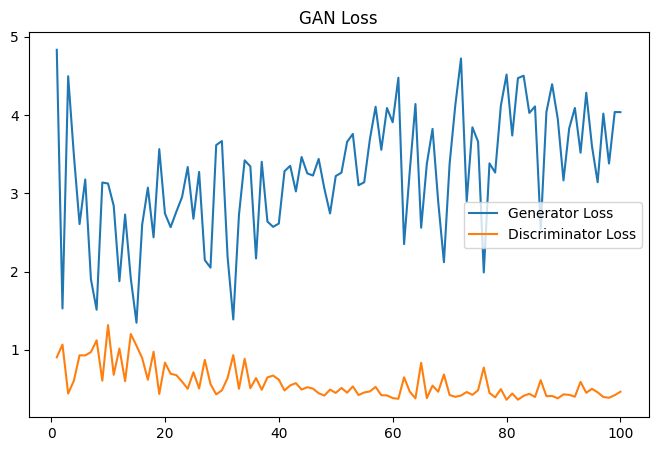

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

loss_df = pd.read_csv("/content/drive/MyDrive/airborne-object-detection/models/helicopter_gan_losses.csv")

plt.figure(figsize=(8,5))
plt.plot(loss_df["epoch"], loss_df["G_loss"], label="Generator Loss")
plt.plot(loss_df["epoch"], loss_df["D_loss"], label="Discriminator Loss")
plt.legend()
plt.title("GAN Loss")
plt.show()

In [23]:
from torchvision.utils import save_image
import os

save_dir = "/content/drive/MyDrive/airborne-object-detection/gan_generated/helicopter"
os.makedirs(save_dir, exist_ok=True)

num_fake = 1200

netG.eval()

with torch.no_grad():
    for i in range(num_fake):
        noise = torch.randn(1, 100, 1, 1, device=device)
        fake = netG(noise).cpu()

        save_image(
            fake,
            f"{save_dir}/gan_helicopter_{i:04d}.png",
            normalize=True
        )

print("Fake helicopter images created:", len(os.listdir(save_dir)))

Fake helicopter images created: 1200


In [24]:
import shutil

src_dataset = "/content/drive/MyDrive/airborne-object-detection/dataset"
dst_dataset = "/content/drive/MyDrive/airborne-object-detection/dataset_augmented"

if os.path.exists(dst_dataset):
    shutil.rmtree(dst_dataset)

shutil.copytree(src_dataset, dst_dataset)

print("Base dataset copied ✔️")

Base dataset copied ✔️


In [25]:
aug_helicopter_dir = dst_dataset + "/train/helicopter"

for f in os.listdir(save_dir):
    src = os.path.join(save_dir, f)
    dst = os.path.join(aug_helicopter_dir, f)

    shutil.copy2(src, dst)

print("Fake helicopter added ✔️")
print("Total helicopter images:", len(os.listdir(aug_helicopter_dir)))

Fake helicopter added ✔️
Total helicopter images: 5455


In [27]:
dataset_path = "/content/drive/MyDrive/airborne-object-detection/dataset_augmented"

In [28]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [32]:
dataset_path = "/content/drive/MyDrive/airborne-object-detection/dataset_augmented"

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "validation")
test_dir = os.path.join(dataset_path, "test")

In [33]:
img_size = 64
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=test_transform)
test_dataset = ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['airplane', 'bird', 'drone', 'helicopter']
Train: 16440
Val: 4445
Test: 2165


In [34]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [35]:
model = SimpleCNN(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [36]:
num_epochs = 10

train_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

Epoch 1/10: Loss=0.6165, Train Acc=0.7372, Val Acc=0.8022
Epoch 2/10: Loss=0.3796, Train Acc=0.8429, Val Acc=0.8682
Epoch 3/10: Loss=0.2825, Train Acc=0.8914, Val Acc=0.8949
Epoch 4/10: Loss=0.2163, Train Acc=0.9175, Val Acc=0.9168
Epoch 5/10: Loss=0.1793, Train Acc=0.9347, Val Acc=0.9204
Epoch 6/10: Loss=0.1437, Train Acc=0.9468, Val Acc=0.9298
Epoch 7/10: Loss=0.1211, Train Acc=0.9559, Val Acc=0.9314
Epoch 8/10: Loss=0.1123, Train Acc=0.9600, Val Acc=0.9325
Epoch 9/10: Loss=0.0975, Train Acc=0.9639, Val Acc=0.9408
Epoch 10/10: Loss=0.0848, Train Acc=0.9686, Val Acc=0.9483


In [37]:
model.eval()

test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / test_total

print("Test Accuracy:", test_acc)

Test Accuracy: 0.9468822170900693


<Figure size 800x800 with 0 Axes>

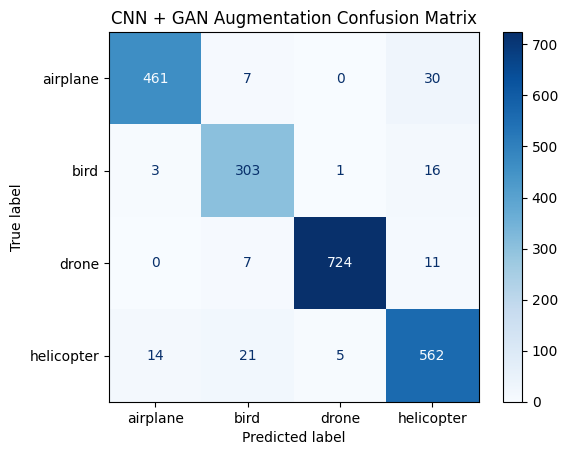

In [38]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues", values_format="d")
plt.title("CNN + GAN Augmentation Confusion Matrix")
plt.show()

In [39]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=test_dataset.classes
))

              precision    recall  f1-score   support

    airplane       0.96      0.93      0.94       498
        bird       0.90      0.94      0.92       323
       drone       0.99      0.98      0.98       742
  helicopter       0.91      0.93      0.92       602

    accuracy                           0.95      2165
   macro avg       0.94      0.94      0.94      2165
weighted avg       0.95      0.95      0.95      2165



In [40]:
import os
import torch

save_path = "/content/drive/MyDrive/airborne-object-detection/models/cnn_gan_augmented.pth"

os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)

print("CNN model saved ✔️")

CNN model saved ✔️


In [41]:
import pandas as pd

results = {
    "test_accuracy": test_acc
}

df = pd.DataFrame([results])
df.to_csv("/content/drive/MyDrive/airborne-object-detection/models/cnn_gan_results.csv", index=False)

print("Results saved ✔️")

Results saved ✔️


In [42]:
plt.savefig("/content/drive/MyDrive/airborne-object-detection/models/cnn_gan_confusion_matrix.png")

<Figure size 640x480 with 0 Axes>